# Filtrer des données et explorer les relations

**Objectif d'apprentissage :**
- Apprendre à filtrer des observations
- Apprendre à comparer des relations
- Apprendre à synthétiser des relations

## Filtrer les observations (lignes)

Généralement, les données c'est "messy", sale/désordonné. La plupart du temps, vous avez besoin de filtrer certaines observations (lignes) dans votre jeu de données.
- Vous vous intéressez à certains aspects particuliers de votre jeu de données (ex : les jeunes électeurs).
- L'information est non pertinente et vous devez supprimer certaines données pour éviter de tirer de mauvaises conclusions (ex : les personnes qui refusent de répondre).

Vous avez donc besoin d'un moyen de filtrer les observations dans votre jeu de données.

- Les opérateurs relationnels permettent de sélectionner des observations.
- Il existe aussi des méthodes utiles pour vous aider dans cette tâche.

![](https://pandas.pydata.org/docs/_images/03_subset_rows.svg)

Nous avons vu que les données de l'ANES contiennent des valeurs comme -8, -9, 99, qui peuvent ou non être utiles selon le problème que l'on souhaite traiter.

Comment peut-on les gérer ?

Commençons par cette question pour illustrer :
- Les jeunes électeurs sont-ils plus libéraux ou conservateurs ?


In [1]:
# Charger pandas
import pandas as pd

# Charger des données avec pandas depuis une URL
data_url = "https://raw.githubusercontent.com/datamisc/ts-2024/main/data.csv"
anes_data = pd.read_csv(data_url, compression="gzip", low_memory=False)


In [2]:
# Sélectionner un sous ensemble de  variables et renommer
my_vars = [
    "V241042",  # a l'intention de voter ou non
    "V241043",  # pour qui a l'intention de voter
    "V241458x",  # age
    "V241177",  # autoplacement sur une échelle libéral-conservateur
    "V241157",  # feeling thermometer Trump
]

df = anes_data[my_vars]
df.columns = ["vote", "vote_int", "age", "ideologie", "trump_thermometer"]

df.head()

,vote,vote_int,age,ideologie,trump_thermometer
0,1,2,50,6,100
1,1,3,41,4,50
2,1,1,44,2,0
3,1,2,45,99,70
4,1,2,80,4,60


<Axes: xlabel='ideologie'>

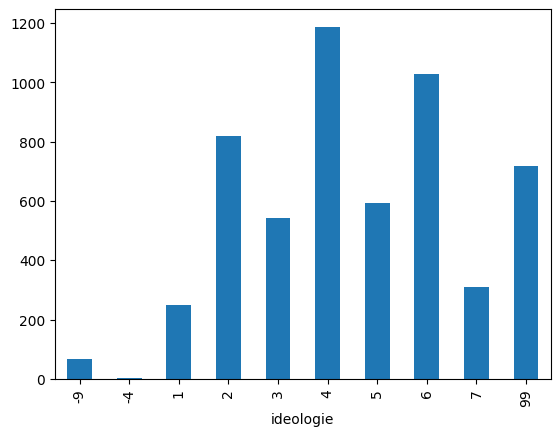

In [4]:
# Quelle est la distribution/répartition par idéologie ?
df.value_counts("ideologie").sort_index().plot(kind="bar")

# nb : .sort_index() permet de trier les barres par ordre alphanumérique de l'index
# (ici, les valeurs de la variable idéologie)
# plutôt que par effectifs

# nb2 : df.value_counts("ideologie") est ici équivalent
# à df["ideologie"].value_counts()
# que l'on avait vu précédemment

<Axes: ylabel='Frequency'>

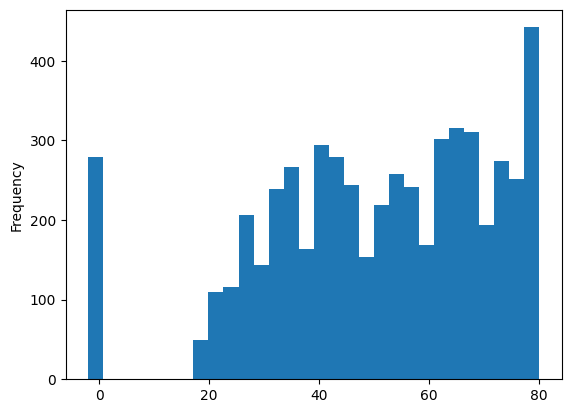

In [5]:
# Quelle est la répartition/distribution par âge ?
df["age"].plot(kind="hist", bins=30)


On a besoin de faire un peu de nettoyage dans ces variables !

In [6]:
# nettoyer la variable âge
mask_age = df["age"] >= 18
mask_age


0        True
1        True
2        True
3        True
4        True
        ...  
5516    False
5517     True
5518    False
5519     True
5520     True
Name: age, Length: 5521, dtype: bool

In [7]:
# L'âge a l'air ok désormais, mais on a perdu des observations !
df[mask_age].describe()


,vote,vote_int,age,ideologie,trump_thermometer
count,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000
mean,0.897177,1.099199,53.150515,16.514880,39.469668
std,0.796095,1.660363,17.347720,32.264763,39.235797
min,-9.000000,-9.000000,18.000000,-9.000000,-9.000000
25%,1.000000,1.000000,39.000000,3.000000,0.000000
50%,1.000000,1.000000,54.000000,4.000000,30.000000
75%,1.000000,2.000000,68.000000,6.000000,80.000000
max,2.000000,6.000000,80.000000,99.000000,100.000000


In [8]:
# Sauvegarder le dataframe avec les données filtrées
df = df[mask_age]

In [ ]:
# Nettoyons la variable idéologie
mask_ideo = (df["ideologie"] >= 1) & (df["ideologie"] <= 7)
mask_ideo

0        True
1        True
2        True
3       False
4        True
        ...  
5514     True
5515     True
5517     True
5519     True
5520     True
Name: ideologie, Length: 5242, dtype: bool

In [ ]:
df = df[mask_ideo]
df.describe()

In [ ]:
# Comment est distribué l'âge désormais ?
df["age"].plot(kind="hist", bins=30)


In [ ]:
# Comment est distribuée l'idéologie maintenant ?
df.value_counts("ideologie").sort_index().plot(kind="bar")

### Hack-Time


In [ ]:
# Nettoyer la variable `vote`


In [ ]:
# Nettoyer la variable `vote_int`


### Qui sont les jeunes électeurs ?

In [ ]:
# Definir les jeunes électeurs
mask = df["age"] <= 80


In [ ]:
# Quel groupe est plus libéral ? Quel groupe est plus conservateur ?
print(df[mask]["ideologie"].mean())
print(df[~mask]["ideologie"].mean())


In [ ]:
# Est-ce qu'on a oublié quelque chose ?


Pourrait-on visualiser cette relation d'une autre manière ?


## Types de données & et mesures

Rappel sur les types de variables :

| **Type**                | **Sous-type**      | **Exemples**                                 | **Type Altair**   |
|-------------------------|-------------------------|-----------------------------------------------|-------------------|
| Numérique (quantitative)| Continue                | Niveau de revenus (1825€)               | quantitative (Q)  |
| Numérique (quantitative)| Discrète                | Nombre d'enfants       | quantitative (Q) / ordinal (O)  |
| Catégorielle (qualitative) | Ordinale             | Jamais/parfois/souvent/toujours              | ordinal (O)       |
| Catégorielle (qualitative) | Nominale             | Genre, couleur de cheveux, discipline         | nominal (N)       |

*NB : il existe en réalité des zones grises*
*NB : et il existe d'autres types dans Altair (temporal (T) : valeur de temps ou date, geojson (G) : forme géographique)*

### Continue & Continue



#### Scatter plot (nuages de points)

In [ ]:
# Quelle est la relation entre age et le sentiment envers D. Trump ?

# filtrons les valeurs pour le thermomètre :
# on peut le faire sans masque en définissant directement le filtre dans les crochets
df = df[df["trump_thermometer"] >= 0]

# Et tentons de faire un nuage de points (scatter plot en anglais)
df.plot(kind="scatter", x="trump_thermometer", y="age", figsize=(10, 10))


### Hack-Time


In [ ]:
# On peut tenter d'améliorer le graphique
# en échantillonnant pour l'alléger
# ou en jouant sur la transparence des points

# Tentez de jouer sur les options sample() et alpha ci-dessous
# N'executez qu'une seule des deux lignes à la fois
# (vous pouvez commenter/décommenter les lignes)

# df.sample(100).plot(kind="scatter", x="trump_thermometer", y="age", figsize=(10, 10))
# df.plot(kind="scatter", x="trump_thermometer", y="age", alpha=0.02, figsize=(10, 10))


### Discrète & Continue | Catégorielle & Continue


#### Groupby et statistiques agrégées

La **fonction `groupby`** de pandas permet de regrouper les données selon les valeurs d'une ou plusieurs colonnes, puis d'appliquer des opérations statistiques (comme la moyenne, la médiane, l'écart-type, etc.) sur chaque groupe.

Cela facilite la comparaison entre différentes catégories ou groupes d'observations.

La syntaxe suit ce format :
```python
df.groupby("colonne_à_grouper")[["autre_colonne"]].operation() # .mean(), .std(), etc.
```

In [ ]:
# regroupons par idéologie et calculons des statistiques sur l'age
df.groupby("ideologie")["age"].mean()  # ou median(), ou std()

### Hack-Time


In [162]:
# Calculez l'age médian par groupe d'idéologie


In [163]:
# Calculez l'écart type (std) d'age par groupe d'idéologie


On sait donc calculer une mediane par groupe, des quartiles, un écart type, etc.

Quelle visualisation marche bien pour ces informations ?

Team "boite à moustache"/boxplot !!

#### Boxplots / boite à moustache

<!-- passage par html pour la taille de l'image -->
<img src="https://miro.medium.com/max/1400/1*2c21SkzJMf3frPXPAR_gZA.png" width="900"/>

In [ ]:
# Pour une boxplot sur une seule variable
df["age"].plot(kind="box")

In [ ]:
# Mais on peut aussi croiser les variables

# Ex : Y a t-il une relation entre age et ideologie ?
df.boxplot(column="age", by="ideologie")


### Discrète & Discrète | catégorielle & catégorielle

#### Tableaux croisés

On peut utiliser la fonction `pd.crosstab()` pour réaliser des tableaux croisés entre deux variables (ou plus) 

<!-- @mickael : le lien est mort, mais je ne sais pas ce que c'était à l'origine
Si tu as un souvenir on peut remettre
![](https://www.dataindependent.com/wp-content/uploads/2020/08/Screen-Shot-2020-08-17-at-7.43.21-AM-1024x466.png)
-->

Pour de l'aide sur une fonction, vous pouvez faire appel à :
```python
help(pd.crosstab)
# ou
pd.crosstab?
```

In [ ]:
# APPELEZ À L'AIDE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [ ]:
# Exemple :
pd.crosstab(df["ideologie"], df["vote_int"])

In [ ]:
# Tableau croisé
pd.crosstab(df["ideologie"], df["vote_int"])


In [ ]:
# Similaire à …
df.groupby("ideologie")["vote_int"].value_counts().unstack().fillna(0).astype(int)


In [ ]:
# Les valeurs absolues ne sont pas très parlantes
# pourcentage du total :
pd.crosstab(df["ideologie"], df["vote_int"], normalize=True)


In [ ]:
# Les barplots à la rescousse !
pd.crosstab(df["ideologie"], df["vote_int"], normalize=True).plot(
    kind="bar",
    # On peut jouer sur les options pour améliorer le rendu :
    # stacked=True,
    # width=0.7,
    # figsize=(10, 6)
)


In [ ]:
# Exemple d'un tableau croisé pourcentages en ligne
tab = pd.crosstab(df["ideologie"], df["vote_int"], normalize="index", margins=True)
(tab * 100).round(2)

In [ ]:
tab.plot(kind="bar", stacked=True, legend=False)